# 10 — Полезная статистика по аналитическим витринам

Этот ноутбук читает уже рассчитанные файлы из `processed/dashboard_stats/`
и показывает только статистику, которая помогает:

- понять структуру данных;
- выбрать информативные графики для дашборда;
- оценить распределения метрик;
- увидеть различия между этапами обучения и `part`;
- найти метрики с сильной асимметрией;
- проверить, какие показатели доступны для дальнейшего анализа.

> Ноутбук ничего тяжёлого не пересчитывает: используются только готовые агрегированные файлы.

## 1. Настройки и загрузка

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

NOTEBOOK_VERSION = "VISUAL_REPORT_V2"
print("VERSION:", NOTEBOOK_VERSION)


def find_dashboard_dir() -> Path:
    candidates = [
        Path("data/processed/dashboard_stats"),
        Path("../data/processed/dashboard_stats"),
        Path("../../data/processed/dashboard_stats"),
        Path("processed/dashboard_stats"),
        Path("../processed/dashboard_stats"),
        Path("../../processed/dashboard_stats"),
    ]
    for p in candidates:
        if (p / "dashboard_kpi.parquet").exists():
            return p

    raise FileNotFoundError(
        "Не найден processed/dashboard_stats. "
        "Сначала запусти расчётный ноутбук статистики."
    )


DASHBOARD_DIR = find_dashboard_dir()

FILES = {
    "kpi": DASHBOARD_DIR / "dashboard_kpi.parquet",
    "metric_summary": DASHBOARD_DIR / "dashboard_metric_summary.parquet",
    "part_summary": DASHBOARD_DIR / "dashboard_part_summary.parquet",
    "stage_summary": DASHBOARD_DIR / "dashboard_stage_summary.parquet",
    "source_inventory": DASHBOARD_DIR / "dashboard_source_inventory.parquet",
    "metric_availability": DASHBOARD_DIR / "dashboard_metric_availability.parquet",
}

for name, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")

kpi = pd.read_parquet(FILES["kpi"])
metric_summary = pd.read_parquet(FILES["metric_summary"])
part_summary = pd.read_parquet(FILES["part_summary"])
stage_summary = pd.read_parquet(FILES["stage_summary"])
source_inventory = pd.read_parquet(FILES["source_inventory"])
metric_availability = pd.read_parquet(FILES["metric_availability"])

print("DASHBOARD_DIR:", DASHBOARD_DIR.resolve())
print()
for name, df in {
    "kpi": kpi,
    "metric_summary": metric_summary,
    "part_summary": part_summary,
    "stage_summary": stage_summary,
    "source_inventory": source_inventory,
    "metric_availability": metric_availability,
}.items():
    print(f"{name:22s}: {df.shape}")

VERSION: VISUAL_REPORT_V2
DASHBOARD_DIR: D:\RACP\data\processed\dashboard_stats

kpi                   : (28, 5)
metric_summary        : (40, 14)
part_summary          : (7, 13)
stage_summary         : (56, 25)
source_inventory      : (4, 5)
metric_availability   : (11, 4)


## 2. Инвентаризация витрин

Количество строк между marts может различаться на несколько порядков.
Поэтому обычная линейная диаграмма почти полностью скрывает маленькие витрины.

Для числа строк используем **логарифмическую шкалу**, при этом рядом с каждым столбцом
показываем реальное значение.

Размер файлов отображается отдельно в MB.

,source,file_name,rows_count,columns_count,size_mb
0,mart_users,mart_users.parquet,393656,28,22.551727
1,mart_questions,mart_questions.parquet,13523,20,1.007000
2,mart_topics,mart_topics.parquet,188,19,0.015308
3,mart_student_stage,mart_student_stage.parquet,56,24,0.020957


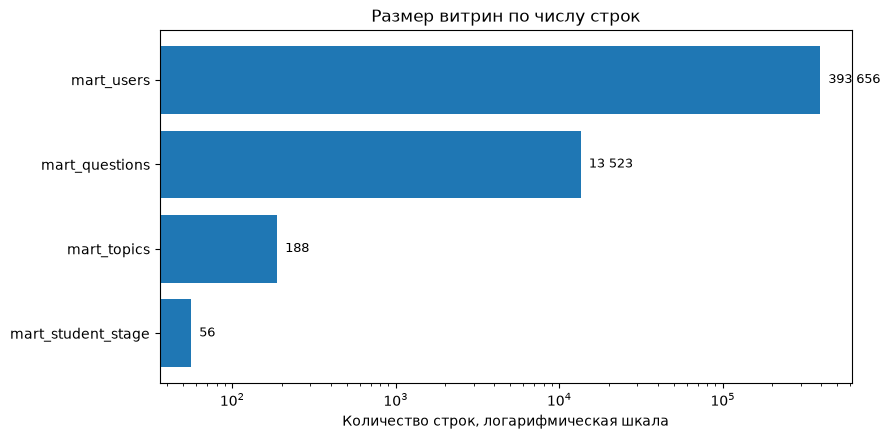

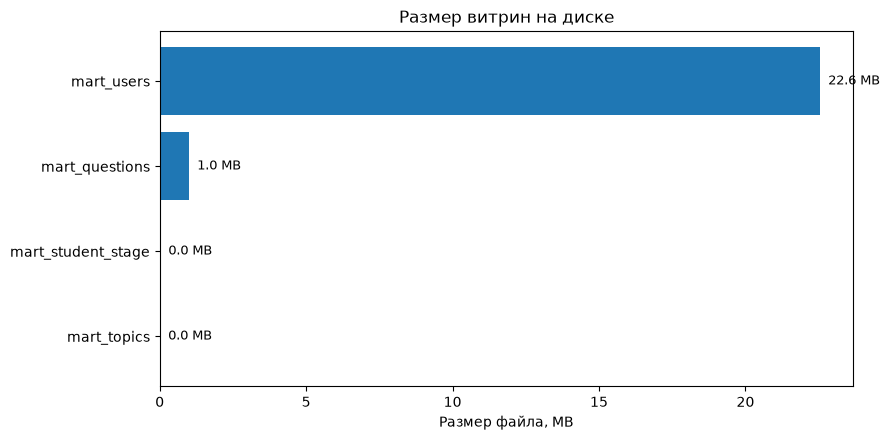

In [4]:
display(source_inventory)

inventory = source_inventory.sort_values("rows_count", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(inventory["source"], inventory["rows_count"])
ax.set_xscale("log")
ax.set_xlabel("Количество строк, логарифмическая шкала")
ax.set_title("Размер витрин по числу строк")

for bar, value in zip(bars, inventory["rows_count"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {int(value):,}".replace(",", " "),
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


inventory_size = source_inventory.sort_values("size_mb", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(inventory_size["source"], inventory_size["size_mb"])
ax.set_xlabel("Размер файла, MB")
ax.set_title("Размер витрин на диске")

for bar, value in zip(bars, inventory_size["size_mb"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {value:,.1f} MB".replace(",", " "),
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## 3. Основные KPI

KPI лучше показывать карточками, а не пытаться сравнивать их на одной диаграмме:
у числа пользователей, accuracy, количества попыток и длительности разные единицы измерения.

In [5]:
def format_value(value, unit):
    if pd.isna(value):
        return "—"

    if unit == "share":
        return f"{value:.2%}"

    if unit == "share_delta":
        return f"{value:+.2%}"

    if unit in {"days", "questions", "attempts", "events", "sessions", "users", "topics"}:
        if float(value).is_integer():
            return f"{int(value):,}".replace(",", " ")
        return f"{value:,.2f}".replace(",", " ")

    return f"{value:,.2f}".replace(",", " ")


kpi_view = kpi.copy()
kpi_view["formatted_value"] = [
    format_value(v, u)
    for v, u in zip(kpi_view["value"], kpi_view["unit"])
]

display(
    kpi_view[
        ["section", "metric", "formatted_value", "description"]
    ]
)

for section in kpi_view["section"].dropna().unique():
    block = kpi_view[kpi_view["section"].eq(section)]

    html_cards = (
        '<div style="display:flex;flex-wrap:wrap;gap:12px;'
        'margin:8px 0 18px 0;">'
    )

    for _, row in block.iterrows():
        html_cards += f"""
        <div style="
            min-width:220px;
            max-width:290px;
            border:1px solid #ddd;
            border-radius:10px;
            padding:12px 14px;
            box-shadow:0 1px 4px rgba(0,0,0,0.06);
        ">
            <div style="font-size:12px;color:#666;text-transform:uppercase;">
                {row['section']}
            </div>
            <div style="font-size:15px;font-weight:600;margin-top:6px;">
                {row['metric']}
            </div>
            <div style="font-size:28px;font-weight:700;margin-top:8px;">
                {row['formatted_value']}
            </div>
            <div style="font-size:12px;color:#666;margin-top:8px;line-height:1.35;">
                {row['description']}
            </div>
        </div>
        """

    html_cards += "</div>"

    display(HTML(f"<h3>{section}</h3>"))
    display(HTML(html_cards))

,section,metric,formatted_value,description
0,volume,users_count,393 656,Количество пользователей в mart_users.
1,volume,sessions_count,5 945 418,Сумма sessions_count по пользователям.
2,volume,question_attempts,99 271 300,Сумма вопросов/попыток по пользователям.
3,volume,lecture_events,1 959 032,Сумма lecture events по пользователям.
4,volume,events_count,101 230 332,Сумма всех событий по пользователям.
5,quality,overall_accuracy,65.72%,Взвешенная accuracy = correct_answers / questi...
6,users,mean_sessions_per_user,15.10,Среднее число сессий на пользователя.
7,users,median_sessions_per_user,2,Медианное число сессий на пользователя.
8,users,mean_unique_questions_per_user,220.67,Среднее число уникальных вопросов на пользоват...
9,users,median_unique_questions_per_user,40,Медианное число уникальных вопросов на пользов...


## 4. Жизненный цикл пользователя

Здесь есть естественная ось порядка — `stage`.

Поэтому для этапов используем **линейные графики**, а не отдельные несвязанные столбцы.

Метрики разделяем по смыслу:

- объём аудитории;
- доли / rates;
- интенсивность учебной сессии;
- время ответа — если оно есть в `stage_summary`.

,aggregation_level,stage_order,stage,stage_min_question,stage_max_question,part,students_count,answers_count,accuracy,median_elapsed_time,mean_elapsed_time,elapsed_time_observations,lectures_count,lecture_students_count,students_without_lectures,lecture_rate,lectures_per_student,explanation_rate,explanation_observations,median_error_streak,sessions_count,avg_questions_per_session,small_sample_flag,sample_size_status,reach_from_stage_1_share
0,stage,1,1–10,1,10,<NA>,393656,3928411,0.507141,21223.362458,24322.908859,3535905,2159,2032,391624,0.005162,0.005484,0.081842,3535905,0,475856,8.255462,False,ok,1.000000
1,stage,2,11–20,11,20,<NA>,390687,3672430,0.502691,19986.401395,22313.372812,3672430,19382,18128,372559,0.046400,0.049610,0.516852,3672430,0,482973,7.603800,False,ok,0.992458
2,stage,3,21–50,21,50,<NA>,332257,7224103,0.585427,20019.458913,24285.175886,7224103,86141,65726,266531,0.197817,0.259260,0.735129,7224103,0,682931,10.578086,False,ok,0.844029
3,stage,4,51–100,51,100,<NA>,174074,7253473,0.644936,19968.377130,24240.644575,7253473,144372,83470,90604,0.479509,0.829371,0.942556,7253473,0,633421,11.451267,False,ok,0.442198
4,stage,5,101–200,101,200,<NA>,123379,10137455,0.654587,20478.837354,25256.813361,10137455,241606,81703,41676,0.662212,1.958242,0.956895,10137455,0,780394,12.990175,False,ok,0.313418
5,stage,6,201–500,201,500,<NA>,84659,18144113,0.664490,21034.630120,26044.997359,18144113,482527,65614,19045,0.775039,5.699654,0.977185,18144113,0,1248021,14.538307,False,ok,0.215058
6,stage,7,501+,501,<NA>,<NA>,44266,48911315,0.691182,21179.477176,25884.751293,48911315,982845,36981,7285,0.835427,22.203158,0.979732,48911315,0,2716513,18.005183,False,ok,0.112448


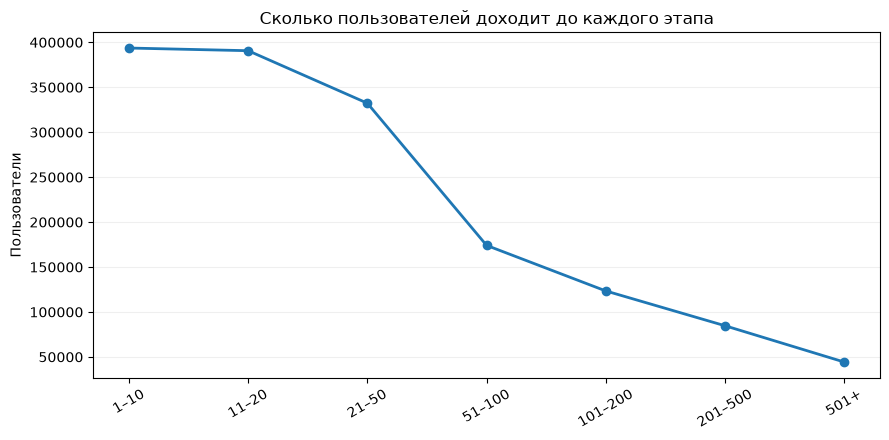

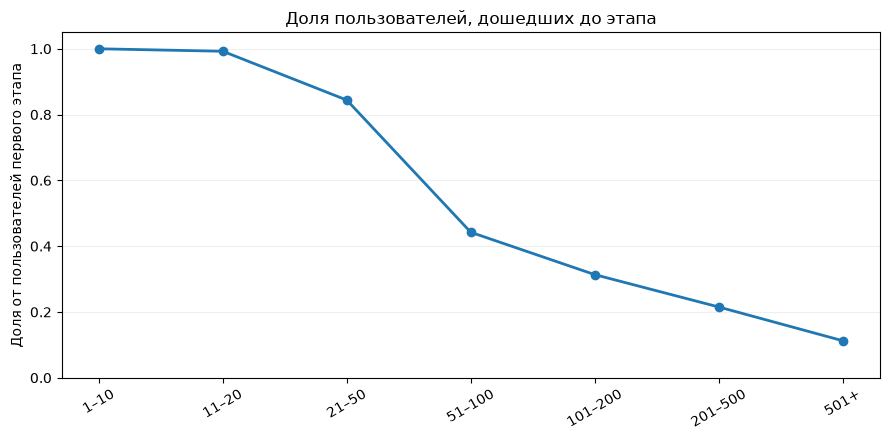

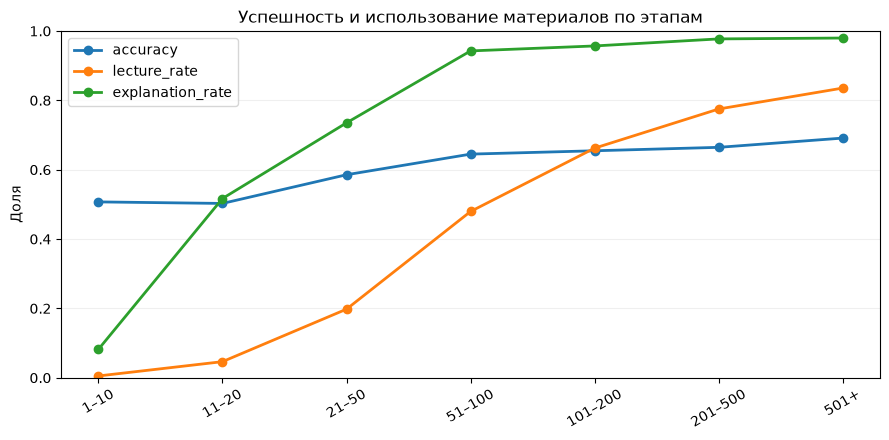

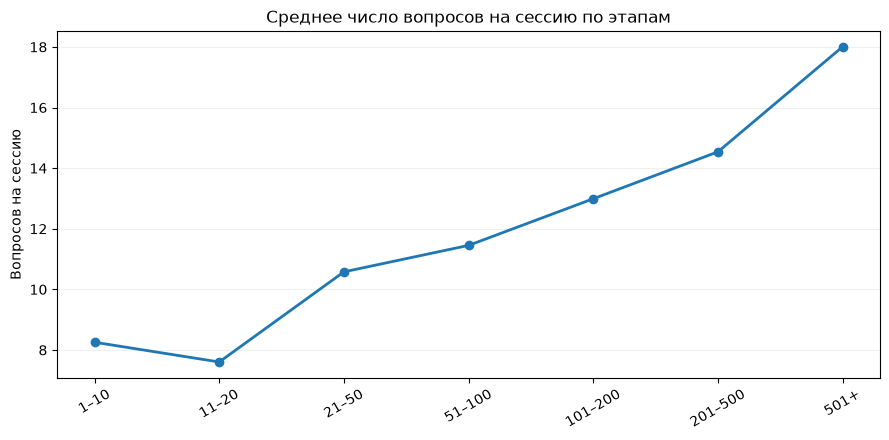

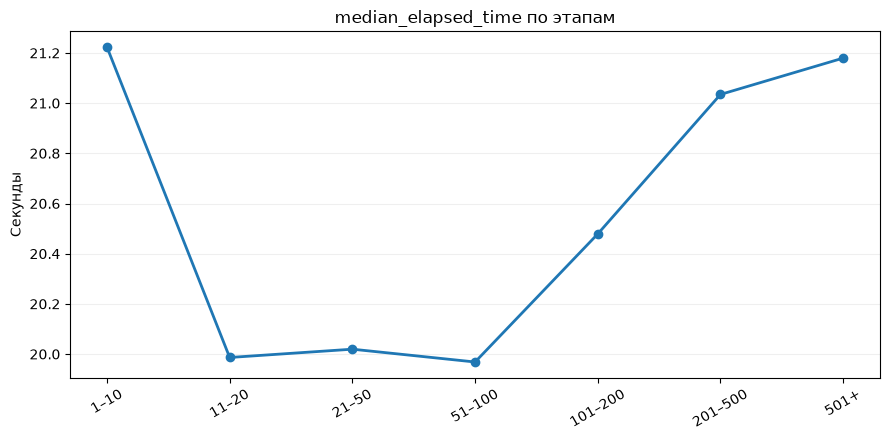

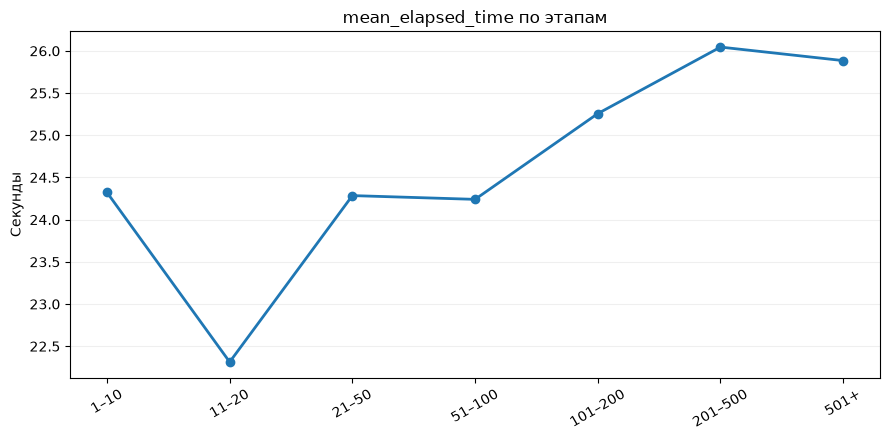

In [6]:
stage_only = (
    stage_summary[
        stage_summary["aggregation_level"].eq("stage")
    ]
    .copy()
    .sort_values("stage_order")
)

display(stage_only)


# 1. Пользователи и воронка.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    stage_only["stage"],
    stage_only["students_count"],
    marker="o",
    linewidth=2,
)
ax.set_ylabel("Пользователи")
ax.set_title("Сколько пользователей доходит до каждого этапа")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


if "reach_from_stage_1_share" in stage_only.columns:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        stage_only["stage"],
        stage_only["reach_from_stage_1_share"],
        marker="o",
        linewidth=2,
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Доля от пользователей первого этапа")
    ax.set_title("Доля пользователей, дошедших до этапа")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


# 2. Сопоставимые rate-метрики.
rate_columns = [
    col for col in [
        "accuracy",
        "lecture_rate",
        "explanation_rate",
    ]
    if col in stage_only.columns
]

if rate_columns:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for col in rate_columns:
        ax.plot(
            stage_only["stage"],
            stage_only[col],
            marker="o",
            linewidth=2,
            label=col,
        )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Доля")
    ax.set_title("Успешность и использование материалов по этапам")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


# 3. Интенсивность сессии.
if "avg_questions_per_session" in stage_only.columns:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        stage_only["stage"],
        stage_only["avg_questions_per_session"],
        marker="o",
        linewidth=2,
    )
    ax.set_ylabel("Вопросов на сессию")
    ax.set_title("Среднее число вопросов на сессию по этапам")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


# 4. Время ответа — отдельная шкала.
for time_col in ["median_elapsed_time", "mean_elapsed_time"]:
    if time_col in stage_only.columns:
        values_sec = stage_only[time_col] / 1000

        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(
            stage_only["stage"],
            values_sec,
            marker="o",
            linewidth=2,
        )
        ax.set_ylabel("Секунды")
        ax.set_title(f"{time_col} по этапам")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()

## 5. Аналитика по `part`

Для `part` полезно смотреть три разных вопроса:

1. **Где больше всего активности?** → `attempts`;
2. **Где пользователи отвечают успешнее?** → `weighted_accuracy`;
3. **Как распределён каталог контента?** → `questions_catalog`.

Дополнительно строим scatter `attempts × weighted_accuracy`.
Он показывает связь между популярностью раздела и наблюдаемой успешностью,
при этом метрики не смешиваются на одной оси.

,part,questions_catalog,questions_seen,attempts,question_user_pairs,correct_answers,incorrect_answers,weighted_accuracy,weighted_difficulty,mean_question_accuracy,median_question_elapsed_time,median_attempts_per_question,questions_enough_attempts
0,1,992,992,7454570,6735835,5553896,1900674,0.745032,0.254968,0.815104,21000.000000,5948.0,642
1,2,1647,1647,18743404,15706116,13283339,5460065,0.708694,0.291306,0.745296,17000.000000,9793.0,1602
2,3,1562,1562,8639907,7706350,6060514,2579393,0.701456,0.298544,0.744598,24000.000000,4951.0,1238
3,4,1439,1439,8067676,7279636,5090684,2976992,0.630998,0.369002,0.724918,24000.000000,4517.0,1040
4,5,5511,5511,40908153,35675224,24957570,15950583,0.610088,0.389912,0.666119,20000.000000,4617.0,5372
5,6,1212,1212,10501472,9064117,7029563,3471909,0.669388,0.330612,0.699596,29860.294118,5179.0,1207
6,7,1160,1160,4956118,4699753,3269061,1687057,0.659601,0.340399,0.717958,54642.288889,2762.0,1070


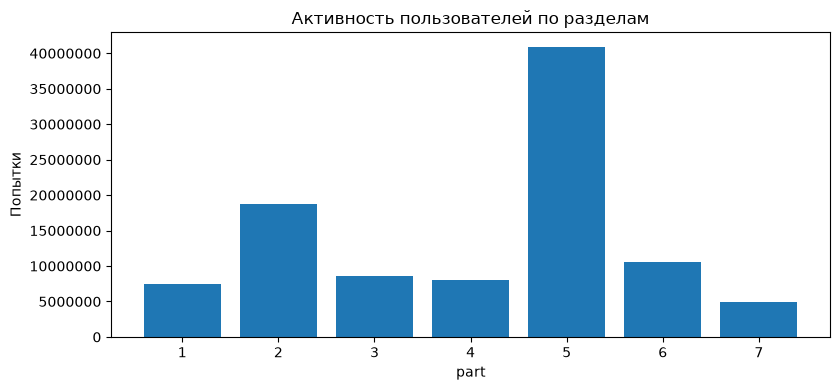

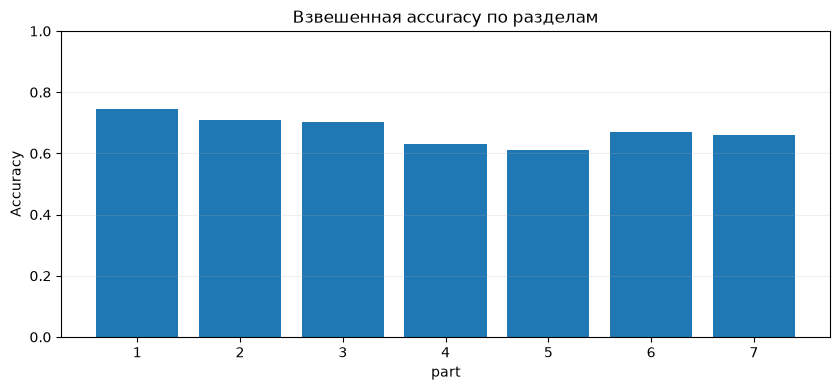

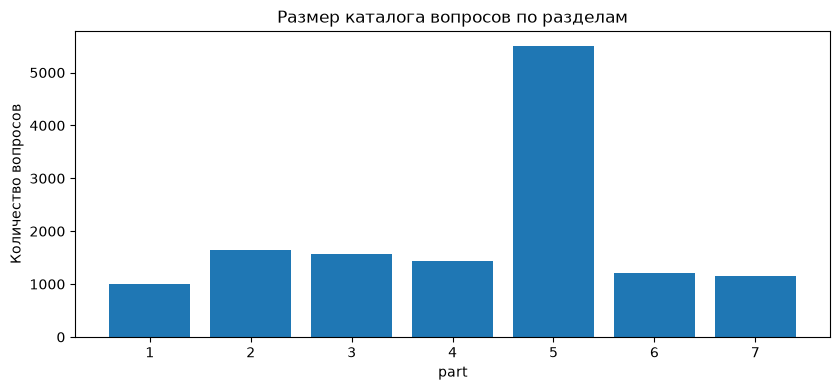

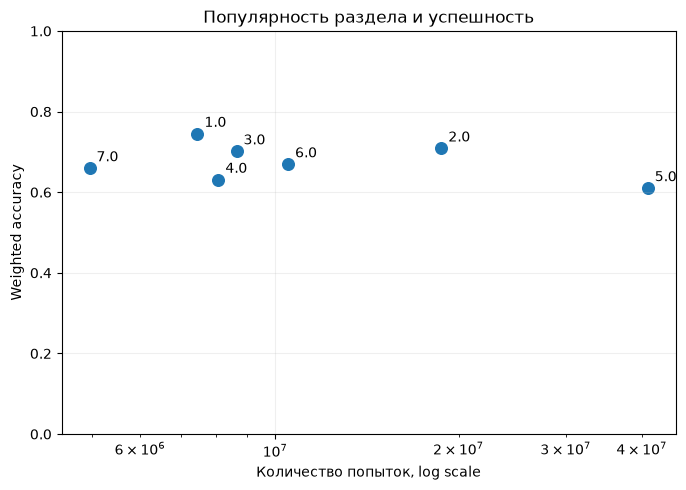

In [7]:
display(part_summary)

part_plot = part_summary.sort_values("part").copy()


if "attempts" in part_plot.columns:
    fig, ax = plt.subplots(figsize=(8.5, 4))
    bars = ax.bar(part_plot["part"].astype(str), part_plot["attempts"])
    ax.set_xlabel("part")
    ax.set_ylabel("Попытки")
    ax.set_title("Активность пользователей по разделам")
    ax.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()
    plt.show()


if "weighted_accuracy" in part_plot.columns:
    fig, ax = plt.subplots(figsize=(8.5, 4))
    ax.bar(
        part_plot["part"].astype(str),
        part_plot["weighted_accuracy"],
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel("part")
    ax.set_ylabel("Accuracy")
    ax.set_title("Взвешенная accuracy по разделам")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


if "questions_catalog" in part_plot.columns:
    fig, ax = plt.subplots(figsize=(8.5, 4))
    ax.bar(
        part_plot["part"].astype(str),
        part_plot["questions_catalog"],
    )
    ax.set_xlabel("part")
    ax.set_ylabel("Количество вопросов")
    ax.set_title("Размер каталога вопросов по разделам")
    plt.tight_layout()
    plt.show()


if {"attempts", "weighted_accuracy"} <= set(part_plot.columns):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        part_plot["attempts"],
        part_plot["weighted_accuracy"],
        s=70,
    )

    for _, row in part_plot.iterrows():
        ax.annotate(
            str(row["part"]),
            (row["attempts"], row["weighted_accuracy"]),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Количество попыток, log scale")
    ax.set_ylabel("Weighted accuracy")
    ax.set_title("Популярность раздела и успешность")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## 6. Сводная статистика метрик

`metric_summary` полезна как таблица распределений.

Важно: **не строим график абсолютных медиан всех метрик вместе**.
У них разные единицы измерения и разные масштабы.

Вместо этого:

- долевые метрики (`share`, `share_delta`) анализируем отдельно;
- для положительных неограниченных метрик оцениваем относительную асимметрию через `p90 / median`.

In [8]:
summary_cols = [
    col for col in [
        "entity_level",
        "metric",
        "unit",
        "n",
        "mean",
        "median",
        "p75",
        "p90",
        "p95",
        "max",
        "description",
    ]
    if col in metric_summary.columns
]

summary_short = metric_summary[summary_cols].copy()

display(
    summary_short.sort_values(
        ["entity_level", "unit", "metric"]
    )
)

,entity_level,metric,unit,n,mean,median,p75,p90,p95,max,description
17,question,attempts,attempts,13523,7.340923e+03,4732.000000,8.563000e+03,1.588800e+04,2.250500e+04,2.136050e+05,Количество попыток по вопросу.
28,question,error_streak_before_avg,count,13523,5.477988e-01,0.546706,6.186913e-01,7.461740e-01,8.633809e-01,8.462271e+00,Средний error streak перед вопросом.
22,question,mean_elapsed_time,ms,13523,2.665457e+04,23351.654578,2.884091e+04,3.826568e+04,5.485516e+04,9.221356e+04,Среднее время ответа по вопросу.
21,question,median_elapsed_time,ms,13523,2.445245e+04,22006.724962,2.599974e+04,3.488527e+04,5.208128e+04,8.900000e+04,Медианное время ответа по вопросу.
19,question,accuracy,share,13523,7.094601e-01,0.734270,8.352426e-01,9.031883e-01,9.337482e-01,1.000000e+00,Accuracy вопроса.
23,question,beginner_accuracy,share,12056,6.148575e-01,0.628257,7.708157e-01,8.988002e-01,1.000000e+00,1.000000e+00,Accuracy начинающих.
20,question,difficulty,share,13523,2.905399e-01,0.265621,3.907595e-01,5.231294e-01,6.086431e-01,1.000000e+00,1 - accuracy.
24,question,experienced_accuracy,share,13523,7.186347e-01,0.744521,8.417524e-01,9.072087e-01,9.371420e-01,1.000000e+00,Accuracy опытных.
26,question,fast_incorrect_rate,share,13523,5.645863e-02,0.043730,7.383790e-02,1.157633e-01,1.491896e-01,1.000000e+00,Доля быстрых неправильных ответов.
27,question,slow_incorrect_rate,share,13523,1.161328e-01,0.086964,1.657334e-01,2.633523e-01,3.339244e-01,1.000000e+00,Доля медленных неправильных ответов.


## 7. Долевые метрики

Все такие показатели находятся на сопоставимой шкале.

Для обычных `share` фиксируем ось `[0, 1]`.

`share_delta` показываем отдельно, потому что разница долей может быть отрицательной.

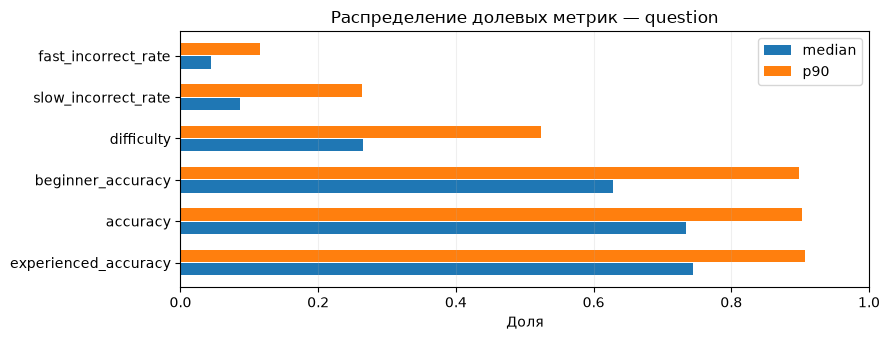

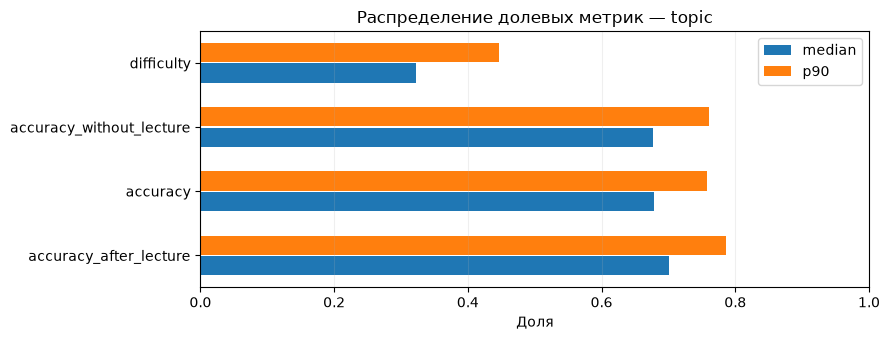

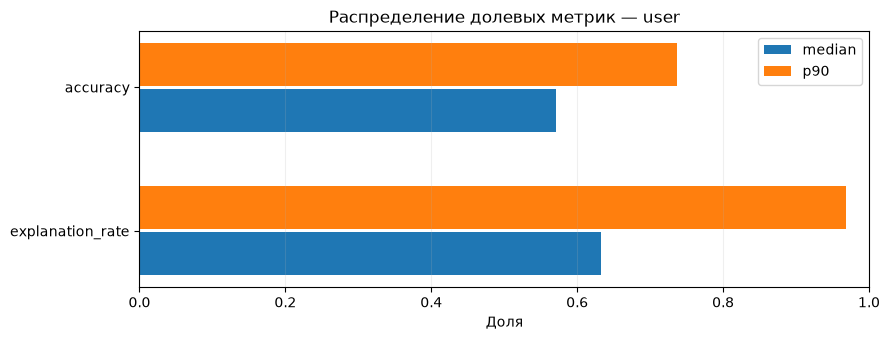

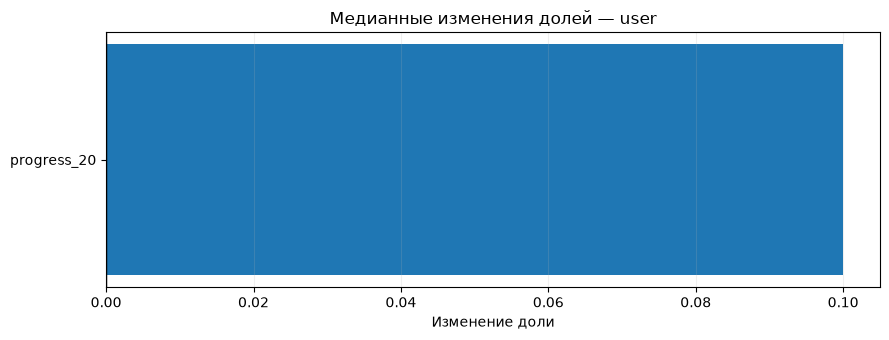

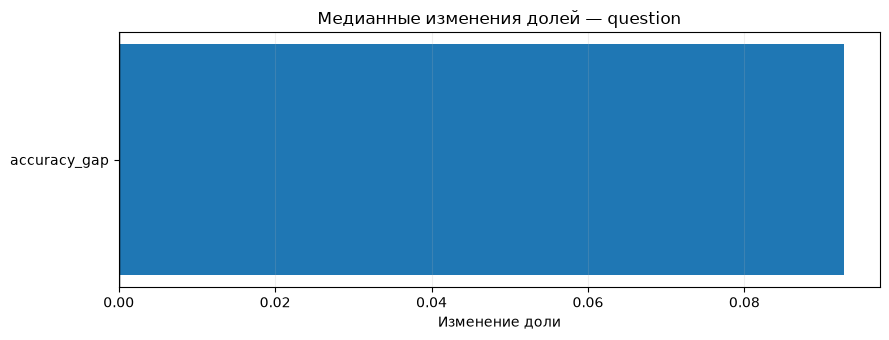

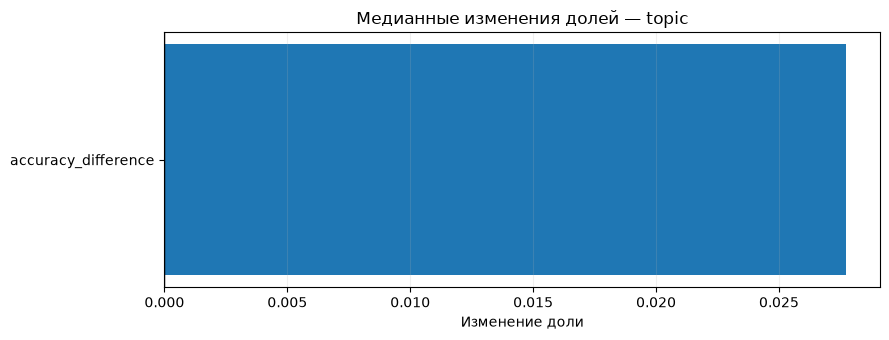

In [9]:
share_metrics = metric_summary[
    metric_summary["unit"].eq("share")
].copy()

if not share_metrics.empty:
    share_metrics = share_metrics.sort_values(
        ["entity_level", "median"],
        ascending=[True, False],
    )

    for entity in share_metrics["entity_level"].dropna().unique():
        block = share_metrics[
            share_metrics["entity_level"].eq(entity)
        ].copy()

        if block.empty:
            continue

        y = np.arange(len(block))

        fig, ax = plt.subplots(
            figsize=(9, max(3.5, 0.45 * len(block)))
        )

        ax.barh(
            y - 0.16,
            block["median"],
            height=0.30,
            label="median",
        )

        if "p90" in block.columns:
            ax.barh(
                y + 0.16,
                block["p90"],
                height=0.30,
                label="p90",
            )

        ax.set_yticks(y)
        ax.set_yticklabels(block["metric"])
        ax.set_xlim(0, 1)
        ax.set_xlabel("Доля")
        ax.set_title(f"Распределение долевых метрик — {entity}")
        ax.legend()
        ax.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        plt.show()


delta_metrics = metric_summary[
    metric_summary["unit"].eq("share_delta")
].copy()

if not delta_metrics.empty:
    for entity in delta_metrics["entity_level"].dropna().unique():
        block = delta_metrics[
            delta_metrics["entity_level"].eq(entity)
        ].copy().sort_values("median")

        fig, ax = plt.subplots(
            figsize=(9, max(3.5, 0.45 * len(block)))
        )

        colors = [
            "tab:red" if x < 0 else "tab:blue"
            for x in block["median"]
        ]

        ax.barh(block["metric"], block["median"], color=colors)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_xlabel("Изменение доли")
        ax.set_title(f"Медианные изменения долей — {entity}")
        ax.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        plt.show()

## 8. Какие метрики имеют длинный хвост

Для положительных count/time-метрик абсолютные значения между собой сравнивать нельзя.

Но можно сравнить **форму распределения**:

`tail_ratio = p90 / median`

Это безразмерная величина.

- около `1` → распределение относительно компактное;
- заметно больше `1` → правый хвост выражен сильнее;
- очень большое значение → средние значения могут быть малоинформативны, лучше использовать median / quantiles.

Долевые показатели и метрики с медианой `<= 0` здесь исключены.

Метрики с наиболее выраженным правым хвостом:


,entity_level,metric,unit,median,p90,p95,tail_ratio_p90_median
12,user,learning_duration_days,days,4.331476,1.984939e+02,3.324845e+02,45.825922
3,user,sessions_count,sessions,2.000000,3.600000e+01,6.900000e+01,18.000000
2,user,events_count,events,41.000000,5.920000e+02,1.180000e+03,14.439024
0,user,questions_count,attempts,41.000000,5.790000e+02,1.150000e+03,14.121951
4,user,unique_questions,questions,40.000000,5.150000e+02,1.019000e+03,12.875000
29,topic,questions_count,questions,56.000000,3.370000e+02,6.560000e+02,6.017857
30,topic,attempts,attempts,531654.000000,2.206504e+06,3.453486e+06,4.150263
17,question,attempts,attempts,4732.000000,1.588800e+04,2.250500e+04,3.357566
36,topic,lecture_views,events,7756.000000,2.461700e+04,3.080500e+04,3.173930
18,question,users_count,users,4304.000000,1.361800e+04,1.904400e+04,3.164033


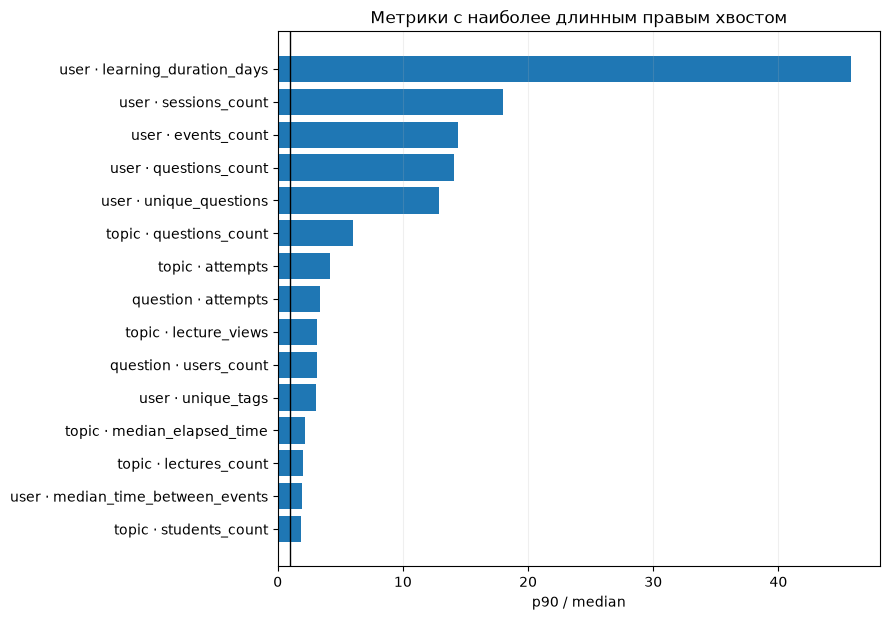

In [10]:
tail = metric_summary.copy()

tail["tail_ratio_p90_median"] = np.where(
    tail["median"].gt(0)
    & tail["p90"].notna(),
    tail["p90"] / tail["median"],
    np.nan,
)

tail = tail[
    ~tail["unit"].isin(["share", "share_delta"])
    & np.isfinite(tail["tail_ratio_p90_median"])
].copy()

tail = tail.sort_values(
    "tail_ratio_p90_median",
    ascending=False,
)

tail_view_cols = [
    col for col in [
        "entity_level",
        "metric",
        "unit",
        "median",
        "p90",
        "p95",
        "tail_ratio_p90_median",
    ]
    if col in tail.columns
]

print("Метрики с наиболее выраженным правым хвостом:")
display(tail[tail_view_cols].head(20))


top_tail = tail.head(15).sort_values(
    "tail_ratio_p90_median"
)

if not top_tail.empty:
    labels = (
        top_tail["entity_level"].astype(str)
        + " · "
        + top_tail["metric"].astype(str)
    )

    fig, ax = plt.subplots(
        figsize=(9, max(4, 0.42 * len(top_tail)))
    )

    ax.barh(
        labels,
        top_tail["tail_ratio_p90_median"],
    )
    ax.axvline(1, color="black", linewidth=1)
    ax.set_xlabel("p90 / median")
    ax.set_title("Метрики с наиболее длинным правым хвостом")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

## 9. Полезные percentile-профили

Если нужно детально посмотреть конкретную метрику,
лучше сравнивать **её собственные квантили**, а не сопоставлять её абсолютную медиану
с другой метрикой.

Ниже автоматически выводятся percentile-профили для выбранных ключевых метрик.

,entity_level,metric,unit,description,n,mean,stddev,min,p25,median,p75,p90,p95,max
19,question,accuracy,share,Accuracy вопроса.,13523,7.094601e-01,1.644864e-01,0.000000,0.609343,0.734270,8.352426e-01,9.031883e-01,9.337482e-01,1.000000e+00
17,question,attempts,attempts,Количество попыток по вопросу.,13523,7.340923e+03,1.145593e+04,1.000000,1772.000000,4732.000000,8.563000e+03,1.588800e+04,2.250500e+04,2.136050e+05
20,question,difficulty,share,1 - accuracy.,13523,2.905399e-01,1.644864e-01,0.000000,0.164618,0.265621,3.907595e-01,5.231294e-01,6.086431e-01,1.000000e+00
32,topic,accuracy,share,Accuracy темы.,188,6.660519e-01,8.157128e-02,0.385725,0.620285,0.678187,7.143975e-01,7.575748e-01,7.962338e-01,8.639452e-01
39,topic,accuracy_difference,share_delta,Разница after lecture - without lecture.,151,4.573487e-02,6.695383e-02,-0.065984,0.002053,0.027724,7.391938e-02,1.361097e-01,1.807341e-01,4.030665e-01
30,topic,attempts,attempts,Число попыток темы.,188,1.250916e+06,2.481004e+06,3367.000000,329868.000000,531654.000000,1.116226e+06,2.206504e+06,3.453486e+06,1.881434e+07
33,topic,difficulty,share,1 - accuracy темы.,188,3.339481e-01,8.157128e-02,0.136055,0.285603,0.321813,3.797146e-01,4.470332e-01,4.796786e-01,6.142752e-01
31,topic,students_count,users,Число пользователей темы.,188,1.292580e+05,7.881620e+04,2626.000000,70156.000000,123620.000000,1.774860e+05,2.330970e+05,2.694120e+05,3.574300e+05
7,user,accuracy,share,Accuracy пользователя.,393656,5.451833e-01,1.633780e-01,0.000000,0.433580,0.570306,6.669302e-01,7.361547e-01,7.741746e-01,1.000000e+00
13,user,avg_questions_per_session,questions,Среднее число вопросов за сессию пользователя.,393656,2.041635e+01,1.156979e+01,1.000000,12.223868,17.688874,2.972429e+01,3.131287e+01,3.999963e+01,4.530000e+02


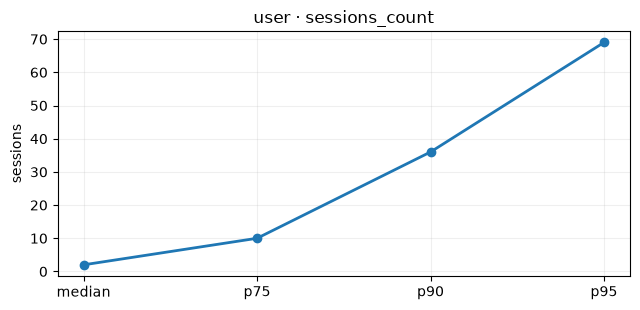

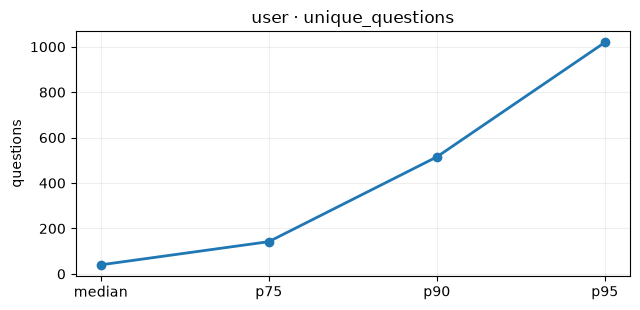

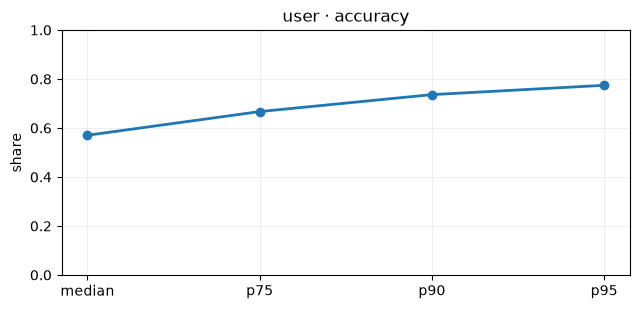

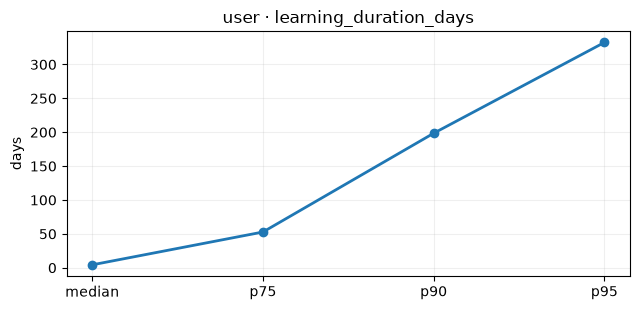

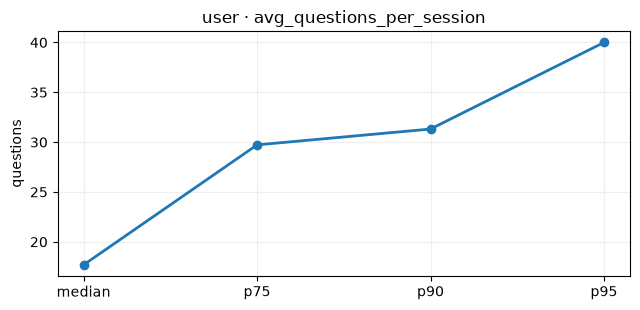

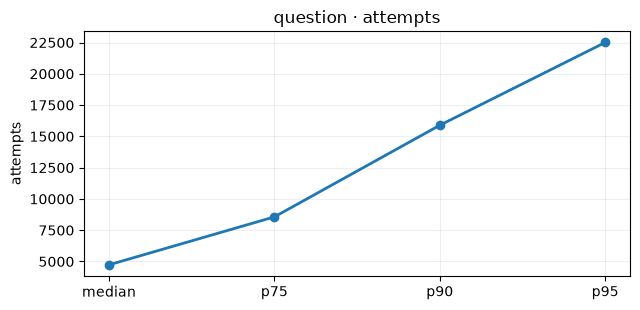

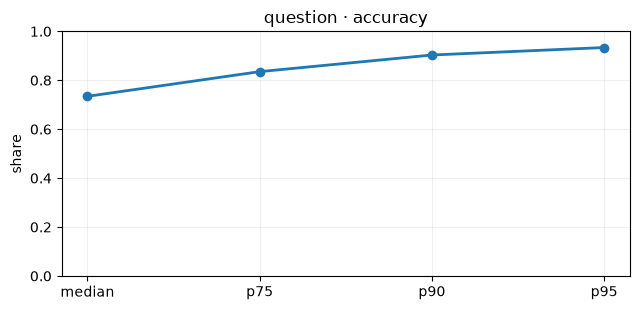

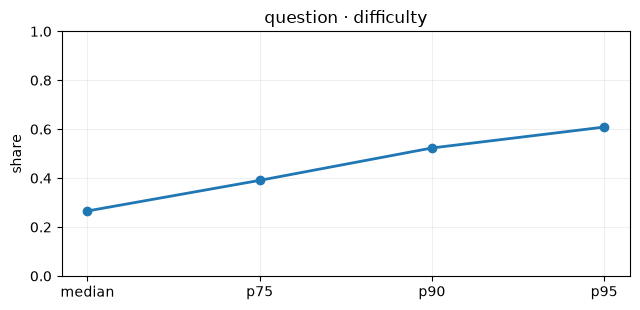

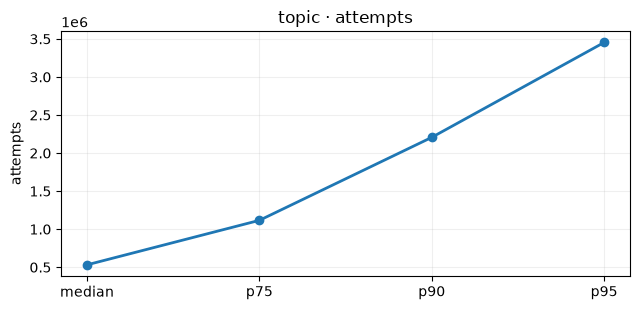

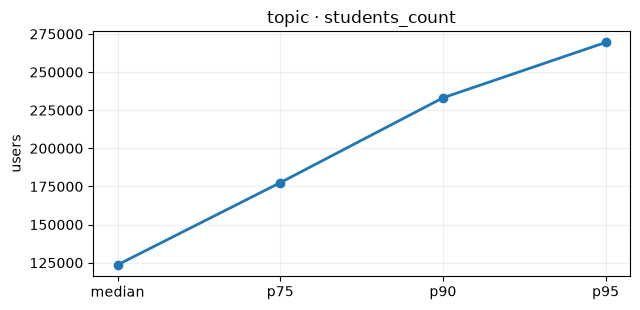

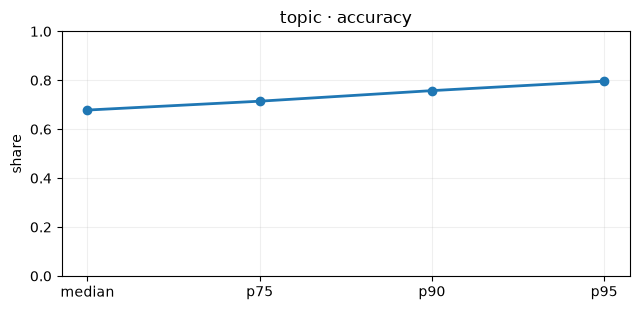

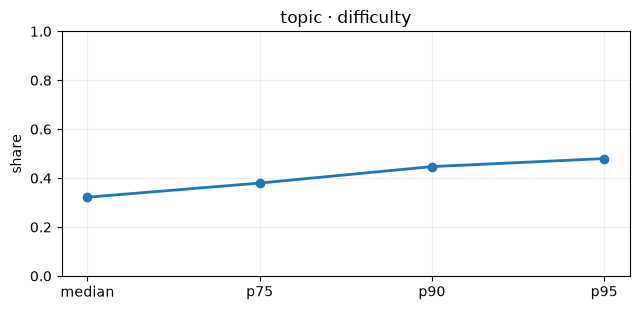

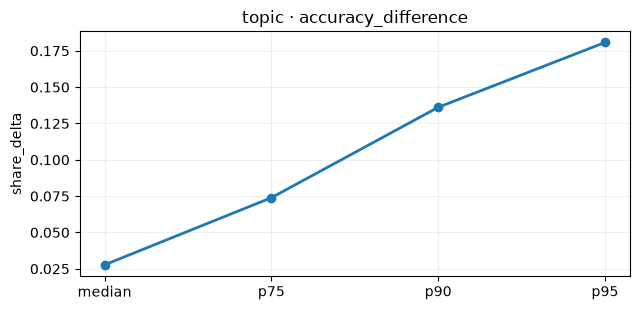

In [11]:
focus_metrics = [
    "sessions_count",
    "unique_questions",
    "accuracy",
    "learning_duration_days",
    "avg_questions_per_session",
    "attempts",
    "difficulty",
    "students_count",
    "accuracy_difference",
]

focus = metric_summary[
    metric_summary["metric"].isin(focus_metrics)
].copy()

display(
    focus.sort_values(["entity_level", "metric"])
)

percentile_cols = [
    col for col in ["median", "p75", "p90", "p95"]
    if col in metric_summary.columns
]

for _, row in focus.iterrows():
    values = [row[col] for col in percentile_cols]

    if all(pd.isna(v) for v in values):
        continue

    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    ax.plot(
        percentile_cols,
        values,
        marker="o",
        linewidth=2,
    )

    if row.get("unit") == "share":
        ax.set_ylim(0, 1)

    ax.set_ylabel(str(row.get("unit", "")))
    ax.set_title(
        f"{row['entity_level']} · {row['metric']}"
    )
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## 10. Доступность метрик

Полезнее не просто знать общее число `True/False`, а увидеть,
**на каком уровне анализа каких показателей не хватает**.

Если в таблице есть `entity_level`, строим доступность отдельно по каждой витрине/уровню.

In [12]:
display(
    metric_availability.sort_values(
        [c for c in ["entity_level", "available", "metric"]
         if c in metric_availability.columns],
        ascending=True,
    )
)

availability = metric_availability.copy()

if "entity_level" in availability.columns:
    availability_summary = (
        availability
        .groupby(["entity_level", "available"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={False: "unavailable", True: "available"})
    )

    for col in ["available", "unavailable"]:
        if col not in availability_summary.columns:
            availability_summary[col] = 0

    display(availability_summary)

    availability_summary[
        ["available", "unavailable"]
    ].plot(
        kind="barh",
        stacked=True,
        figsize=(9, 4.5),
    )
    plt.xlabel("Количество метрик")
    plt.ylabel("")
    plt.title("Доступность метрик по уровню анализа")
    plt.tight_layout()
    plt.show()

else:
    counts = availability["available"].value_counts()

    display(
        pd.DataFrame({
            "available": [
                counts.get(True, 0),
                counts.get(False, 0),
            ]
        }, index=["Да", "Нет"])
    )

,metric,available,source,comment
10,questions_per_individual_session_distribution,False,,Есть только avg_questions_per_session пользова...
9,session_duration,False,,В текущих mart нет start/end или duration отде...
2,avg_questions_per_session,True,mart_users / mart_student_stage,Есть на уровне пользователя и этапа.
5,question_accuracy_difficulty,True,mart_questions,Есть готовые accuracy/difficulty и количество ...
1,sessions_count,True,mart_users.sessions_count,Суммарное число сессий можно получить без собы...
7,stage_funnel,True,mart_student_stage,Есть students_count по этапам.
6,topic_statistics,True,mart_topics,"Есть attempts, students, accuracy, lectures и ..."
4,unique_questions_catalog,True,mart_questions.question_id,Одна строка = один question_id.
3,unique_questions_per_user,True,mart_users.unique_questions,Можно строить распределение по пользователям.
8,user_learning_duration,True,mart_users.learning_duration_days,"Это span всей активности пользователя, не отде..."


,available
Да,9
Нет,2


## 11. Короткие таблицы для подготовки дашборда

Здесь оставлены только таблицы, которые действительно помогают принимать решения:

- этапы жизненного цикла;
- `part` по объёму активности;
- `part` по accuracy;
- метрики с наиболее сильным правым хвостом;
- недоступные показатели.

Удалены рейтинги вроде `TOP metrics by max`, потому что сравнивать максимум
`attempts`, `accuracy`, `days` и других несопоставимых единиц бессмысленно.

In [13]:
stage_cols = [
    col for col in [
        "stage_order",
        "stage",
        "students_count",
        "answers_count",
        "accuracy",
        "lecture_rate",
        "explanation_rate",
        "sessions_count",
        "avg_questions_per_session",
    ]
    if col in stage_only.columns
]

print("Жизненный цикл:")
display(stage_only[stage_cols])


if "attempts" in part_summary.columns:
    print("Part по активности:")
    display(
        part_summary.sort_values(
            "attempts",
            ascending=False,
        )
    )


if "weighted_accuracy" in part_summary.columns:
    print("Part по observed accuracy:")
    cols = [
        c for c in [
            "part",
            "attempts",
            "weighted_accuracy",
            "questions_catalog",
        ]
        if c in part_summary.columns
    ]

    display(
        part_summary[cols].sort_values(
            "weighted_accuracy",
            ascending=True,
        )
    )


print("Самые асимметричные положительные метрики:")
display(tail[tail_view_cols].head(15))


print("Недоступные метрики:")
display(
    metric_availability[
        ~metric_availability["available"]
    ]
)

Жизненный цикл:


,stage_order,stage,students_count,answers_count,accuracy,lecture_rate,explanation_rate,sessions_count,avg_questions_per_session
0,1,1–10,393656,3928411,0.507141,0.005162,0.081842,475856,8.255462
1,2,11–20,390687,3672430,0.502691,0.046400,0.516852,482973,7.603800
2,3,21–50,332257,7224103,0.585427,0.197817,0.735129,682931,10.578086
3,4,51–100,174074,7253473,0.644936,0.479509,0.942556,633421,11.451267
4,5,101–200,123379,10137455,0.654587,0.662212,0.956895,780394,12.990175
5,6,201–500,84659,18144113,0.664490,0.775039,0.977185,1248021,14.538307
6,7,501+,44266,48911315,0.691182,0.835427,0.979732,2716513,18.005183


Part по активности:


,part,questions_catalog,questions_seen,attempts,question_user_pairs,correct_answers,incorrect_answers,weighted_accuracy,weighted_difficulty,mean_question_accuracy,median_question_elapsed_time,median_attempts_per_question,questions_enough_attempts
4,5,5511,5511,40908153,35675224,24957570,15950583,0.610088,0.389912,0.666119,20000.000000,4617.0,5372
1,2,1647,1647,18743404,15706116,13283339,5460065,0.708694,0.291306,0.745296,17000.000000,9793.0,1602
5,6,1212,1212,10501472,9064117,7029563,3471909,0.669388,0.330612,0.699596,29860.294118,5179.0,1207
2,3,1562,1562,8639907,7706350,6060514,2579393,0.701456,0.298544,0.744598,24000.000000,4951.0,1238
3,4,1439,1439,8067676,7279636,5090684,2976992,0.630998,0.369002,0.724918,24000.000000,4517.0,1040
0,1,992,992,7454570,6735835,5553896,1900674,0.745032,0.254968,0.815104,21000.000000,5948.0,642
6,7,1160,1160,4956118,4699753,3269061,1687057,0.659601,0.340399,0.717958,54642.288889,2762.0,1070


Part по observed accuracy:


,part,attempts,weighted_accuracy,questions_catalog
4,5,40908153,0.610088,5511
3,4,8067676,0.630998,1439
6,7,4956118,0.659601,1160
5,6,10501472,0.669388,1212
2,3,8639907,0.701456,1562
1,2,18743404,0.708694,1647
0,1,7454570,0.745032,992


Самые асимметричные положительные метрики:


,entity_level,metric,unit,median,p90,p95,tail_ratio_p90_median
12,user,learning_duration_days,days,4.331476,1.984939e+02,3.324845e+02,45.825922
3,user,sessions_count,sessions,2.000000,3.600000e+01,6.900000e+01,18.000000
2,user,events_count,events,41.000000,5.920000e+02,1.180000e+03,14.439024
0,user,questions_count,attempts,41.000000,5.790000e+02,1.150000e+03,14.121951
4,user,unique_questions,questions,40.000000,5.150000e+02,1.019000e+03,12.875000
29,topic,questions_count,questions,56.000000,3.370000e+02,6.560000e+02,6.017857
30,topic,attempts,attempts,531654.000000,2.206504e+06,3.453486e+06,4.150263
17,question,attempts,attempts,4732.000000,1.588800e+04,2.250500e+04,3.357566
36,topic,lecture_views,events,7756.000000,2.461700e+04,3.080500e+04,3.173930
18,question,users_count,users,4304.000000,1.361800e+04,1.904400e+04,3.164033


Недоступные метрики:


,metric,available,source,comment
9,session_duration,False,,В текущих mart нет start/end или duration отде...
10,questions_per_individual_session_distribution,False,,Есть только avg_questions_per_session пользова...
